### RaschPy centrality MFRM worked example

This notebook works through a sample Rasch analysis of a simulated data set (200 persons, 12 items with a maximum score of 5, all rated by 8 raters, no missing data), taking you through the relevant commands step by step, with notes before each cell. Relevant outputs will appear below each cell.

The `centrality` parameterisation (Jin & Wang, 2018) is a rater centrality/extremity model. It restricts the fully-free `thresholds` parameterisation (a separate severity per rater x threshold combination) down to just two parameters per rater: a global severity shift `lambda_r` and a threshold-stretch `omega_r`. A value of `omega_r > 1` spreads the reference thresholds apart for that rater, corresponding to central tendency (when `lambda_r` is close to zero) or restricted range (when `lambda_r` is far from zero): a larger person-location difference is needed to cross a category, so extreme categories are under-used); `0 < omega_r < 1` compresses the threshold structure, corresponding to extreme tendency. `omega_r == 1` is neutral and collapses to the `global` model. `centrality` sits between `global` (1 free parameter per rater) and `thresholds` (`m` free parameters per rater, where `m` is the maximum score); it can therefore be compared against both directly via `model_selection()`. The model also has a descriptive alias, `threshold_stretch` in parallel to the `thresholds` model, of which it is a restricted case (see also `item_stretch` for the `pseudo_halo` model, and `bistretch` for the combined model, analogous to the `bivector` model).

Import the modules and set the working directory (here called `my_working_directory`) to where you want to save your output files.

**References**

Jin, K.-Y., & Wang, W.-C. (2018). A new facets model for rater's centrality/extremity response style. *Journal of Educational Measurement*, *55*(4), 543–563.

In [1]:
import raschpy as rp
import pandas as pd
import os

os.chdir('my_working_directory')

**A note on data validation**

Every model constructor validates the item-response network automatically at instantiation (`validate=True` by default) and warns if it's disconnected – if there's no chain of persons and items linking every item to every other, the resulting item locations aren't on a common scale, even though `calibrate()` will still run without error. This is worth seeing happen once. Here we build a small, deliberately disconnected data set: two groups of persons who each only answer a disjoint set of items, with no item shared between the groups to link them:

In [2]:
sim_disconnected = rp.MFRM_Sim_Thresholds(no_of_items=8, no_of_persons=40, no_of_facet_elements=4, max_score=5, seed=1234)
responses_disconnected = sim_disconnected.responses.copy()
persons = responses_disconnected.index.get_level_values(1).unique()
group_a, group_b = persons[:20], persons[20:]
responses_disconnected.loc[(slice(None), group_a), responses_disconnected.columns[4:]] = float('nan')   # group A: only items 1-4
responses_disconnected.loc[(slice(None), group_b), responses_disconnected.columns[:4]] = float('nan')    # group B: only items 5-8

broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning

/Users/markelliott/Documents/GitHub/RaschPy/raschpy/mfrm.py:392: UserWarning: The data is split into 2 disconnected sub-networks. This will break un-smoothed calibrations. Isolated groupings: Sub-group 1 (size 4): ['Item_1', 'Item_2', 'Item_3', 'Item_4']; Sub-group 2 (size 4): ['Item_5', 'Item_6', 'Item_7', 'Item_8']
  self.connectivity_status = self.check_data_connectivity()
/var/folders/hs/f4mv8_3d65bf5fln8jlxhxpc0000gn/T/ipykernel_37202/2938571539.py:8: UserWarning: 
⚠️  CRITICAL DATA INTEGRITY WARNING: The response data is disconnected into 2 separate sub-networks.
Item location estimates will be problematic because there are no empirical comparisons spanning across these isolated groups, the item parameter estimates for each independent subset will separately sum to zero. This means items belonging to different subsets cannot be compared or calibrated onto a single scale.
  broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning


`connectivity_status` records the diagnosis, including which items ended up in which isolated sub-group:

In [3]:
broken_mfrm.connectivity_status

{'connected': False,
 'components_count': 2,
 'isolated_items': [],
 'all_sub_groups': [['Item_1', 'Item_2', 'Item_3', 'Item_4'],
  ['Item_5', 'Item_6', 'Item_7', 'Item_8']],
 'directionally_isolated_items': []}

The rest of this notebook uses a single, fully-connected simulated data set, so this warning won't come up again.

Simulate a data set. Passing `seed=1234` makes the simulation fully reproducible – rerunning this notebook will always generate the same data set. 12 items, 8 raters, 200 persons, no missing data. We simulate under the dedicated `MFRM_Sim_Centrality` simulator, which generates data with *true* `lambda_r`/`omega_r` stretch structure directly, for a genuine parameter recovery check further down.

In [4]:
sim = rp.MFRM_Sim_Centrality(no_of_items=12, no_of_persons=200, no_of_facet_elements=8, max_score=5, missing=0, seed=1234)
sim.responses.to_csv('mfrm_centrality_scores.csv')

If you have your own response data saved to a CSV file instead of simulating it, use `loadup_mfrm_single()` to load and validate it. Demonstrated here by reloading the file we just saved:

In [5]:
data, invalid_responses = rp.loadup_mfrm_single('mfrm_centrality_scores.csv', max_score=5)

Check the data - view the first two lines

In [6]:
data.head(2)

Item_1  Item_2  Item_3  Item_4  Item_5  Item_6  Item_7  \
Rater   Person                                                             
Rater_1 Person_1     0.0     0.0     0.0     0.0     0.0     1.0     1.0   
        Person_2     1.0     0.0     1.0     1.0     1.0     1.0     2.0   

                  Item_8  Item_9  Item_10  Item_11  Item_12  
Rater   Person                                               
Rater_1 Person_1     1.0     0.0      1.0      0.0      0.0  
        Person_2     1.0     2.0      1.0      1.0      1.0

Check for any invalid responses (not usable for estimation purposes and excluded)

In [7]:
invalid_responses

,,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Rater,Person,,,,,,,,,,,,


Create an MFRM object. Passing the simulation object `sim` directly (rather than the reloaded `data`) attaches the generating parameters under `mfrm.generating`, which lets us check parameter recovery further down. If you're analysing your own data, pass a DataFrame instead (e.g. `rp.MFRM(data)`).

In [8]:
mfrm = rp.MFRM(sim)

Calibrate under the centrality parameterisation. This first runs the full `thresholds` PAIR estimation internally (a separate severity per rater x threshold combination), then closed-form derives each rater's `lambda_r`/`omega_r`. The `%%time` "magic function" returns the time taken to run the cell contents (algorithm run time in this case).

In [9]:
%%time
mfrm.calibrate_centrality()

CPU times: user 19.3 ms, sys: 384 μs, total: 19.7 ms
Wall time: 19.5 ms


`lambda_r/omega_r` are recovered per rater via a robust regression of that rater's raw free-model deviation values against the reference item/threshold values, controlled by `regression='huber'` (default) or `regression='theil-sen'`. `'huber'` was the most accurate of several methods tested empirically (see the manual for the comparison); `'theil-sen'` (median of pairwise slopes, fully closed-form) is a close second, with no iterative fit to converge. If `'huber'` fails to converge for a given rater, that rater automatically falls back to `'theil-sen'` with a `UserWarning` naming it – the rest are unaffected:

In [10]:
mfrm_theilsen = rp.MFRM(sim)
mfrm_theilsen.calibrate_centrality(regression='theil-sen')

`centrality` has an axis-based alias, `threshold_stretch`, matching the naming of `items`/`thresholds` and `bistretch` itself. It works anywhere a model name is accepted – both as the `model=`/`models=` value and as a method-name suffix – and results still land under the same `_centrality`-suffixed attribute names regardless of which spelling calibrated them:

In [11]:
mfrm_alias = rp.MFRM(sim)
mfrm_alias.calibrate_threshold_stretch()   # identical to calibrate_centrality()
(mfrm_alias.lambda_centrality == mfrm.lambda_centrality).all(), (mfrm_alias.omega_centrality == mfrm.omega_centrality).all()

(np.True_, np.True_)

Check the item location estimates - view the first two items

In [12]:
mfrm.items.head(2)

Item_1    0.020618
Item_2    0.513699
dtype: float64

Since this is simulated data, we know the true generating item locations (`mfrm.generating.items`) and can check how closely the calibration recovered them. The helper below plots generating vs. estimated values, with an identity line (dashed dark red) and a fitted regression line (dashed red) – the closer the points hug the identity line, the better the recovery. Also displays the Pearson correlation, SD ratio, regression coefficient and RMSE:

In [13]:
import numpy as np
from matplotlib import pyplot as plt

def recovery_plot(generating, estimated, label, filename):
    x, y = np.asarray(generating), np.asarray(estimated)
    fig, ax = plt.subplots()
    ax.scatter(x, y, alpha=0.6)
    lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], color='DarkRed', label='Identity')
    m, b = np.polyfit(x, y, 1)
    ax.plot([lo, hi], [m * lo + b, m * hi + b], color='Red', linestyle='--', label='Regression')
    ax.set_xlabel(f'Generating {label}')
    ax.set_ylabel(f'Estimated {label}')
    ax.set_aspect('equal')
    ax.legend()
    plt.savefig(filename)
    plt.show()
    print(f'{label} Pearson correlation:              {round(np.corrcoef(x, y)[0, 1], 3)}')
    print(f'{label} SD ratio (estimated / generating): {round(y.std() / x.std(), 3)}')
    print(f'{label} Regression coefficient:            {round(m, 3)}')
    print(f'{label} RMSE:                               {round(float(np.sqrt(np.mean((x - y) ** 2))), 3)}')

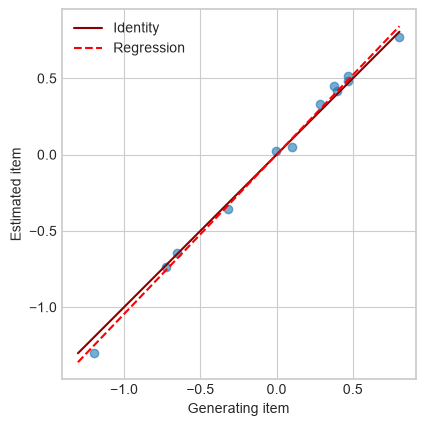

item Pearson correlation:              0.998
item SD ratio (estimated / generating): 1.047
item Regression coefficient:            1.045
item RMSE:                               0.047


In [14]:
recovery_plot(mfrm.generating.items, mfrm.items, 'item', 'my_mfrm_centrality_item_recovery.png')

Generate a table of item statistics (and check run time), and save to file

In [15]:
%%time
mfrm.item_stats_df_centrality(full=True)
mfrm.item_stats_centrality.to_csv('mfrm_centrality_item_stats.csv')

CPU times: user 29.5 s, sys: 186 ms, total: 29.7 s
Wall time: 29.6 s


Check the item statistics table

In [16]:
mfrm.item_stats_centrality

,Estimate,SE,2.5%,97.5%,Count,Facility,Infit MS,Infit Z,Outfit MS,Outfit Z,PM corr,Exp PM corr
Item_1,0.021,0.044,-0.061,0.115,1600,0.499,0.945,-1.562,0.913,-2.500,0.766,0.759
Item_2,0.514,0.043,0.431,0.602,1600,0.420,1.080,2.186,1.073,2.015,0.745,0.750
Item_3,0.415,0.042,0.335,0.500,1600,0.432,1.149,3.983,1.141,3.768,0.745,0.752
Item_4,0.330,0.044,0.242,0.413,1600,0.443,0.986,-0.382,0.949,-1.445,0.753,0.754
Item_5,0.483,0.041,0.408,0.566,1600,0.425,0.993,-0.174,0.987,-0.347,0.754,0.751
Item_6,0.052,0.037,-0.021,0.125,1600,0.484,1.034,0.940,1.012,0.353,0.754,0.759
Item_7,-0.736,0.045,-0.833,-0.659,1600,0.621,0.975,-0.681,0.956,-1.223,0.753,0.756
Item_8,-1.302,0.054,-1.405,-1.202,1600,0.692,0.941,-1.679,0.901,-2.843,0.746,0.738
Item_9,0.769,0.045,0.687,0.863,1600,0.366,0.983,-0.464,1.006,0.176,0.741,0.742
Item_10,-0.354,0.041,-0.434,-0.270,1600,0.552,1.023,0.656,1.035,0.977,0.760,0.760


Generate a table of threshold statistics (and check run time), and save to file

In [17]:
%%time
mfrm.threshold_stats_df_centrality(full=True)
mfrm.threshold_stats_centrality.to_csv('mfrm_centrality_threshold_stats.csv')

CPU times: user 96.4 ms, sys: 2.02 ms, total: 98.4 ms
Wall time: 98.2 ms


Check the threshold statistics table

In [18]:
mfrm.threshold_stats_centrality

,Estimate,SE,2.5%,97.5%,Infit MS,Infit Z,Outfit MS,Outfit Z,Discrim,PM corr,Exp PM corr
Threshold 1,-2.115,0.047,-2.203,-2.012,1.014,1.110,1.022,1.061,0.973,0.650,0.662
Threshold 2,-0.031,0.038,-0.105,0.048,1.007,0.617,1.004,0.204,0.984,0.451,0.466
Threshold 3,0.217,0.037,0.144,0.286,0.998,-0.214,0.995,-0.313,1.008,0.298,0.304
Threshold 4,0.463,0.037,0.384,0.533,0.995,-0.410,0.993,-0.423,1.015,0.328,0.338
Threshold 5,1.467,0.049,1.361,1.547,1.011,1.056,1.015,0.929,0.967,0.500,0.501


And the same recovery check for thresholds, against `mfrm.generating.thresholds`:

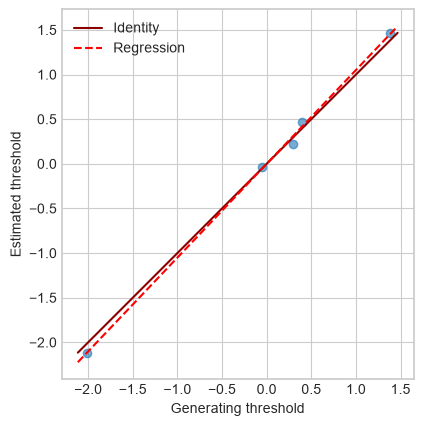

threshold Pearson correlation:              0.999
threshold SD ratio (estimated / generating): 1.052
threshold Regression coefficient:            1.051
threshold RMSE:                               0.076


In [19]:
recovery_plot(mfrm.generating.thresholds, mfrm.thresholds, 'threshold', 'my_mfrm_centrality_threshold_recovery.png')

Generate a table of rater statistics (and check run time), and save to file

In [20]:
%%time
mfrm.rater_stats_df_centrality()
mfrm.rater_stats_centrality.to_csv('mfrm_centrality_rater_stats.csv')
mfrm.rater_stats_centrality_full_vector.to_csv('mfrm_centrality_rater_stats_full_vector.csv')

CPU times: user 45.1 ms, sys: 1.03 ms, total: 46.1 ms
Wall time: 45.9 ms


Check the rater statistics table

In [21]:
mfrm.rater_stats_centrality

lambda           omega        Overall statistics                   
        Estimate     SE Estimate     SE              Count Infit MS Outfit MS
Rater_1    1.299  0.059    1.536  0.039             2400.0    1.001     1.002
Rater_2   -0.200  0.042    0.536  0.030             2400.0    0.981     0.973
Rater_3    0.976  0.046    0.662  0.035             2400.0    1.019     0.963
Rater_4   -0.448  0.043    0.864  0.040             2400.0    1.017     1.000
Rater_5   -0.218  0.036    1.245  0.031             2400.0    1.017     1.024
Rater_6   -0.751  0.040    1.201  0.036             2400.0    1.000     0.977
Rater_7   -0.400  0.036    0.980  0.029             2400.0    1.064     1.028
Rater_8   -0.267  0.036    0.973  0.026             2400.0    1.004     0.997

`self.rater_stats_centrality` (above) is the model's own raw shift/stretch parameters (`lambda`, `omega`), each with its own bootstrap SE. The same call also stores the reconstructed full severity vector separately.

In [22]:
mfrm.rater_stats_centrality_full_vector

Threshold 1        Threshold 2        Threshold 3        Threshold 4  \
           Estimate     SE    Estimate     SE    Estimate     SE    Estimate   
Rater_1       0.164  0.063       1.283  0.059       1.415  0.065       1.547   
Rater_2       0.781  0.071      -0.186  0.046      -0.301  0.046      -0.415   
Rater_3       1.692  0.078       0.986  0.049       0.902  0.049       0.819   
Rater_4      -0.159  0.086      -0.443  0.042      -0.477  0.046      -0.511   
Rater_5      -0.737  0.075      -0.225  0.037      -0.165  0.039      -0.105   
Rater_6      -1.176  0.090      -0.757  0.041      -0.708  0.040      -0.658   
Rater_7      -0.358  0.073      -0.400  0.036      -0.405  0.036      -0.409   
Rater_8      -0.210  0.061      -0.266  0.036      -0.272  0.037      -0.279   

               Threshold 5        Overall statistics                     
            SE    Estimate     SE              Count Infit MS Outfit MS  
Rater_1  0.076       2.086  0.109             2400.0    1.001     1.002  
Rater_2  0.045      -0.881  0.066             2400.0    0.981     0.973  
Rater_3  0.052       0.479  0.073             2400.0    1.019     0.963  
Rater_4  0.051      -0.647  0.078             2400.0    1.017     1.000  
Rater_5  0.040       0.142  0.058             2400.0    1.017     1.024  
Rater_6  0.039      -0.456  0.058             2400.0    1.000     0.977  
Rater_7  0.038      -0.429  0.055             2400.0    1.064     1.028  
Rater_8  0.040      -0.306  0.057             2400.0    1.004     0.997

The two parameters themselves `lambda_centrality` (severity shift) and `omega_centrality` (threshold stretch) are the two parameters the model produces per rater – `mfrm.raters_centrality` above is just their reconstruction back into full (rater x threshold) form, for compatibility with all the same downstream fit-statistic and plotting machinery the other rater parameterisations use. The term `lambda` is used for the global severity since it is an additive parameter, as for instance in the `thresholds` model, so `lambda` is consistent with the notation used elsewhere in the package. `omega` is used for the stretch parameter, following Jin & Wang (2018)'s own notation for a rater stretch factor – it is a multiplicative parameter rather than an additive one, so has a distinct Greek letter to distinguish it from from the additive shift. A rater near `omega=1` is showing undistorted category-width perceptions; well above 1 is central tendency (or restricted range); well below 1 is extreme tendency.

In [23]:
pd.DataFrame({'lambda (severity)': mfrm.lambda_centrality, 'omega (stretch)': mfrm.omega_centrality}).round(3)

,lambda (severity),omega (stretch)
Rater_1,1.299,1.536
Rater_2,-0.200,0.536
Rater_3,0.976,0.662
Rater_4,-0.448,0.864
Rater_5,-0.218,1.245
Rater_6,-0.751,1.201
Rater_7,-0.400,0.980
Rater_8,-0.267,0.973


Pass `alias=True` to `rater_stats_df_centrality()` to relabel these columns with a human-readable name instead of the raw parameter name – `'Global'` for `lambda`, `'Threshold stretch'` for `omega`. Purely cosmetic, values remain unchanged:

In [24]:
mfrm.rater_stats_df_centrality(alias=True)
mfrm.rater_stats_centrality

Global        Threshold stretch        Overall statistics           \
        Estimate     SE          Estimate     SE              Count Infit MS   
Rater_1    1.299  0.059             1.536  0.039             2400.0    1.001   
Rater_2   -0.200  0.042             0.536  0.030             2400.0    0.981   
Rater_3    0.976  0.046             0.662  0.035             2400.0    1.019   
Rater_4   -0.448  0.043             0.864  0.040             2400.0    1.017   
Rater_5   -0.218  0.036             1.245  0.031             2400.0    1.017   
Rater_6   -0.751  0.040             1.201  0.036             2400.0    1.000   
Rater_7   -0.400  0.036             0.980  0.029             2400.0    1.064   
Rater_8   -0.267  0.036             0.973  0.026             2400.0    1.004   

                   
        Outfit MS  
Rater_1     1.002  
Rater_2     0.973  
Rater_3     0.963  
Rater_4     1.000  
Rater_5     1.024  
Rater_6     0.977  
Rater_7     1.028  
Rater_8     0.997

To add an item-by-item divergence test comparing `centrality`'s vector reconstruction against `thresholds`' own free per-item estimates to see which rater-threshold combinations, if any, show significant deviation from the uniform threshold stretching pattern and then inspect the per-rater flagged items and total count:

`divergence_test='wald'` references the test statistic against the standard normal distribution; `divergence_test='t'` uses a plain Student's t-distribution with `no_of_samples - 1` degrees of freedom instead, correcting (a little) for finite-bootstrap-sample uncertainty in the SE estimate itself. In practice `'t'` is only relevant when `no_of_samples` has deliberately been dropped for speed – at `no_of_samples=300` or more, `'wald'` and `'t'` give essentially the same p-values. With a larger `no_of_samples`, there is no reason to prefer `'t'` over `'wald'`.

Passing `full=True` adds one plain True/False column per threshold to the primary table itself, directly after the `'Flagged categories'` count, for scanning flagged status across all elements at a glance – and `rater_stats_centrality_full_vector` receives a per-element `'Flagged'` column added to each threshold's own `Estimate`/`SE`/CI block displaying the same information alongside. The full `mfrm.rater_stats_centrality` is displayed here transposed using `.T` for visual convenience.

In [25]:
mfrm.rater_stats_df_centrality(full=True, divergence_test='wald', correction='bh')
mfrm.rater_stats_centrality.T

Rater_1 Rater_2 Rater_3 Rater_4 Rater_5 Rater_6  \
lambda             Estimate    1.299    -0.2   0.976  -0.448  -0.218  -0.751   
                   SE          0.059    0.04   0.046   0.045   0.036   0.039   
                   2.5%         1.18  -0.277   0.897  -0.533  -0.286  -0.833   
                   97.5%        1.41  -0.131   1.071  -0.358  -0.141  -0.684   
omega              Estimate    1.536   0.536   0.662   0.864   1.245   1.201   
                   SE          0.039   0.031   0.034   0.038    0.03   0.038   
                   2.5%        1.473   0.468   0.591   0.769   1.193    1.13   
                   97.5%       1.621   0.586   0.723    0.92   1.305   1.278   
Flagged categories Count         0.0     0.0     0.0     1.0     0.0     0.0   
Threshold 1        Flagged     False   False   False    True   False   False   
Threshold 2        Flagged     False   False   False   False   False   False   
Threshold 3        Flagged     False   False   False   False   False   False   
Threshold 4        Flagged     False   False   False   False   False   False   
Threshold 5        Flagged     False   False   False   False   False   False   
Overall statistics Count      2400.0  2400.0  2400.0  2400.0  2400.0  2400.0   
                   Infit MS    1.001   0.981   1.019   1.017   1.017     1.0   
                   Infit Z     0.038  -0.552   0.575   0.531   0.559   0.026   
                   Outfit MS   1.002   0.973   0.963     1.0   1.024   0.977   
                   Outfit Z    0.076  -0.518  -0.727   0.009   0.695  -0.597   

                             Rater_7 Rater_8  
lambda             Estimate     -0.4  -0.267  
                   SE          0.035   0.036  
                   2.5%        -0.46  -0.352  
                   97.5%      -0.324   -0.21  
omega              Estimate     0.98   0.973  
                   SE          0.032   0.027  
                   2.5%        0.924   0.919  
                   97.5%       1.047   1.024  
Flagged categories Count         0.0     0.0  
Threshold 1        Flagged     False   False  
Threshold 2        Flagged     False   False  
Threshold 3        Flagged     False   False  
Threshold 4        Flagged     False   False  
Threshold 5        Flagged     False   False  
Overall statistics Count      2400.0  2400.0  
                   Infit MS    1.064   1.004  
                   Infit Z     1.995    0.13  
                   Outfit MS   1.028   0.997  
                   Outfit Z    0.722  -0.057

Recovery check on `mfrm.generating.lambda_`/`mfrm.generating.omega`. Plotted separately since they are on different scales:

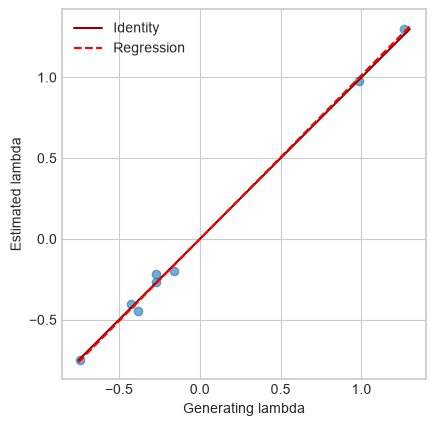

lambda Pearson correlation:              0.999
lambda SD ratio (estimated / generating): 1.016
lambda Regression coefficient:            1.014
lambda RMSE:                               0.037


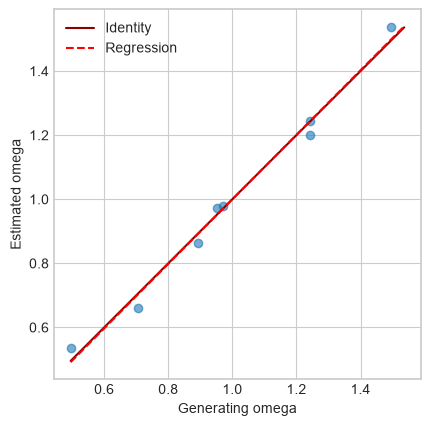

omega Pearson correlation:              0.994
omega SD ratio (estimated / generating): 1.013
omega Regression coefficient:            1.007
omega RMSE:                               0.033


In [26]:
recovery_plot(mfrm.generating.lambda_, mfrm.lambda_centrality, 'lambda', 'my_mfrm_centrality_lambda_recovery.png')
recovery_plot(mfrm.generating.omega, mfrm.omega_centrality, 'omega', 'my_mfrm_centrality_omega_recovery.png')

Generate a table of person statistics (and check run time), and save to file

In [27]:
%%time
mfrm.person_stats_df_centrality(full=True)
mfrm.person_stats_centrality.to_csv('mfrm_centrality_person_stats.csv')

CPU times: user 14.3 ms, sys: 646 μs, total: 15 ms
Wall time: 14.8 ms


Check the person statistics table - view the first ten persons with `.head(10)`

In [28]:
mfrm.person_stats_centrality.head(10)

,Estimate,CSEM,RSEM,Score,Max score,p,Infit MS,Outfit MS,Infit Z,Outfit Z
Person_1,-2.802,0.188,0.173,42,480,0.088,0.851,0.769,-0.734,-0.941
Person_2,0.021,0.095,0.091,233,480,0.485,0.917,0.894,-0.584,-0.699
Person_3,1.033,0.104,0.119,341,480,0.710,1.311,1.279,1.895,1.601
Person_4,0.092,0.094,0.094,241,480,0.502,0.992,0.994,-0.014,0.007
Person_5,1.099,0.106,0.107,347,480,0.723,1.018,0.932,0.167,-0.359
Person_6,4.327,0.345,0.333,471,480,0.981,0.931,0.796,-0.073,0.049
Person_7,-2.000,0.148,0.151,71,480,0.148,1.041,1.102,0.274,0.601
Person_8,1.361,0.113,0.118,369,480,0.769,1.098,1.197,0.633,1.090
Person_9,-2.634,0.179,0.165,47,480,0.098,0.855,0.809,-0.710,-0.941
Person_10,0.394,0.095,0.097,275,480,0.573,1.051,1.068,0.414,0.501


And the same recovery check for person locations, against `mfrm.generating.persons`:

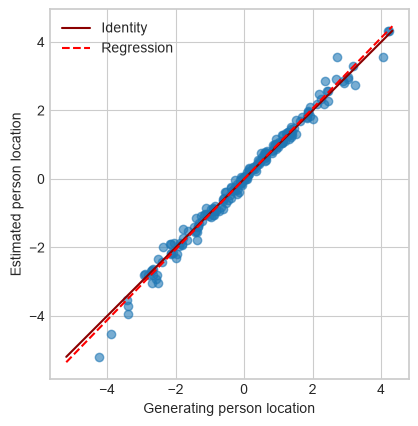

person location Pearson correlation:              0.994
person location SD ratio (estimated / generating): 1.036
person location Regression coefficient:            1.03
person location RMSE:                               0.184


In [29]:
recovery_plot(mfrm.generating.persons, mfrm.persons_centrality, 'person location', 'my_mfrm_centrality_person_recovery.png')

Generate a table of test-level statistics (and check run time), and save to file

In [30]:
%%time
mfrm.test_stats_df_centrality()
mfrm.test_stats_centrality.to_csv('mfrm_centrality_test_stats.csv')

CPU times: user 2.61 ms, sys: 432 μs, total: 3.05 ms
Wall time: 2.95 ms


Check the test statistics table

In [31]:
mfrm.test_stats_centrality

,Items,Persons
Mean,-0.000,0.001
SD,0.629,1.680
Separation ratio,14.374,12.305
Strata,19.499,16.741
Reliability,0.995,0.993


Run an item residual correlation analysis (and check run time), and save relevant output to file

In [32]:
%%time
mfrm.item_res_corr_analysis_centrality()
mfrm.item_residual_correlations_centrality.to_csv('mfrm_centrality_item_residual_correlations.csv')
mfrm.item_loadings_centrality.to_csv('mfrm_centrality_item_loadings.csv')

CPU times: user 7.41 ms, sys: 2.79 ms, total: 10.2 ms
Wall time: 14.7 ms


View the table of pairwise standard residual correlations (pairwise local item independence check)

In [33]:
round(mfrm.item_residual_correlations_centrality, 3)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Item_1,1.000,0.024,-0.032,-0.013,0.032,-0.035,-0.037,0.024,-0.004,0.023,0.002,-0.029
Item_2,0.024,1.000,-0.057,-0.033,-0.031,-0.053,0.005,0.009,-0.031,-0.038,-0.004,0.002
Item_3,-0.032,-0.057,1.000,-0.024,0.025,-0.016,-0.015,-0.011,0.021,-0.047,-0.018,0.013
Item_4,-0.013,-0.033,-0.024,1.000,-0.051,0.007,-0.014,-0.022,0.007,0.026,-0.048,0.008
Item_5,0.032,-0.031,0.025,-0.051,1.000,-0.051,-0.007,0.009,0.018,-0.055,-0.005,-0.027
Item_6,-0.035,-0.053,-0.016,0.007,-0.051,1.000,-0.020,-0.002,-0.027,-0.004,-0.024,-0.012
Item_7,-0.037,0.005,-0.015,-0.014,-0.007,-0.020,1.000,-0.059,-0.048,-0.008,0.019,-0.026
Item_8,0.024,0.009,-0.011,-0.022,0.009,-0.002,-0.059,1.000,0.001,-0.069,0.002,0.042
Item_9,-0.004,-0.031,0.021,0.007,0.018,-0.027,-0.048,0.001,1.000,0.015,-0.022,-0.048
Item_10,0.023,-0.038,-0.047,0.026,-0.055,-0.004,-0.008,-0.069,0.015,1.000,-0.034,-0.005


View the item loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [34]:
round(mfrm.item_loadings_centrality['PC 1'], 3)

Item_1    -0.054
Item_2    -0.072
Item_3    -0.044
Item_4     0.160
Item_5    -0.143
Item_6     0.111
Item_7     0.025
Item_8    -0.118
Item_9     0.017
Item_10    0.179
Item_11   -0.082
Item_12   -0.007
Name: PC 1, dtype: float64

Run a rater residual correlation analysis (and check run time), and save relevant output to file

In [35]:
%%time
mfrm.rater_res_corr_analysis_centrality()
mfrm.rater_residual_correlations_centrality.to_csv('mfrm_centrality_rater_residual_correlations.csv')
mfrm.rater_loadings_centrality.to_csv('mfrm_centrality_rater_loadings.csv')

CPU times: user 12.1 ms, sys: 641 μs, total: 12.8 ms
Wall time: 12.7 ms


View the table of pairwise standard residual correlations (pairwise local rater independence check)

In [36]:
round(mfrm.rater_residual_correlations_centrality, 3)

,Rater_1,Rater_2,Rater_3,Rater_4,Rater_5,Rater_6,Rater_7,Rater_8
Rater_1,1.000,0.021,-0.017,0.002,-0.032,0.029,0.030,-0.003
Rater_2,0.021,1.000,0.008,-0.007,0.004,0.006,-0.007,0.001
Rater_3,-0.017,0.008,1.000,-0.030,-0.007,0.001,-0.035,0.001
Rater_4,0.002,-0.007,-0.030,1.000,-0.037,-0.028,-0.037,-0.047
Rater_5,-0.032,0.004,-0.007,-0.037,1.000,-0.007,-0.048,0.045
Rater_6,0.029,0.006,0.001,-0.028,-0.007,1.000,-0.025,-0.058
Rater_7,0.030,-0.007,-0.035,-0.037,-0.048,-0.025,1.000,-0.035
Rater_8,-0.003,0.001,0.001,-0.047,0.045,-0.058,-0.035,1.000


View the rater loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [37]:
round(mfrm.rater_loadings_centrality['PC 1'], 3)

Rater_1   -0.166
Rater_2   -0.012
Rater_3    0.089
Rater_4   -0.112
Rater_5    0.214
Rater_6   -0.119
Rater_7   -0.111
Rater_8    0.227
Name: PC 1, dtype: float64

Produce an item characteristic curve (item response function) curve for Item 2, with observed category means plotted and the central item location marked

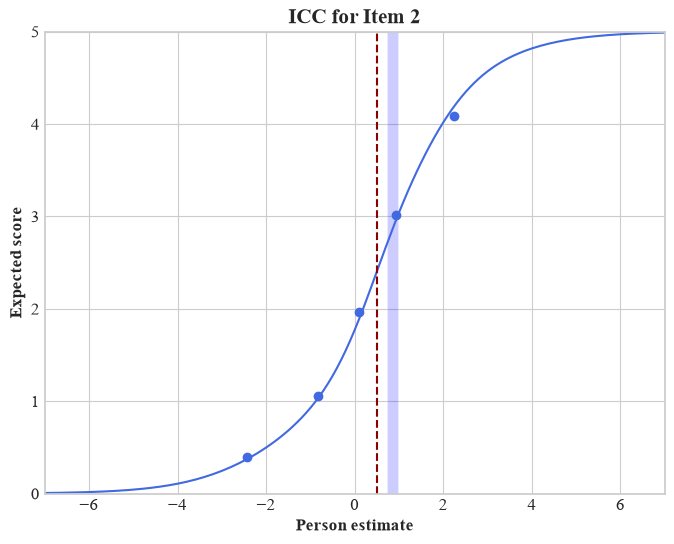

In [38]:
mfrm.icc_centrality('Item_2', title='ICC for Item 2', obs=True, central_location=True, cat_highlight=3, xmin=-7, xmax=7, filename='my_mfrm_centrality_icc')

Produce a set of category response curves for Item 2, with category 1 highlighted and the thresholds marked

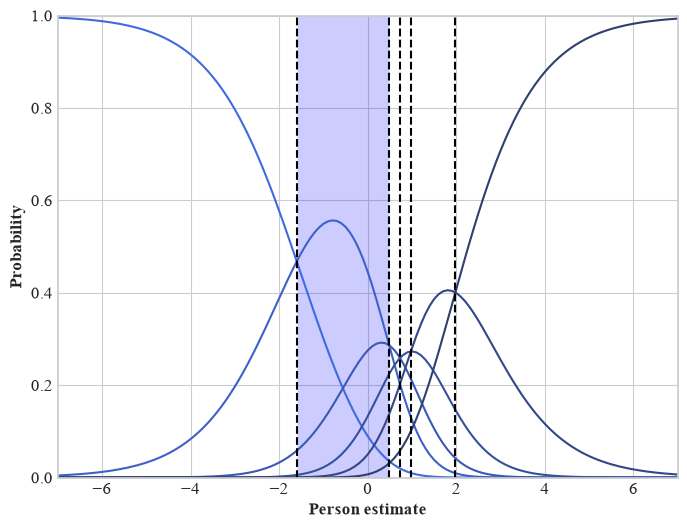

In [39]:
mfrm.crcs_centrality('Item_2', thresh_lines=True, cat_highlight=1, xmin=-7, xmax=7, filename='my_mfrm_centrality_crcs')

Produce a set of threshold characteristic curves for Item 2, with observed category means plotted for threshold 5, category 1 highlighted and the thresholds marked

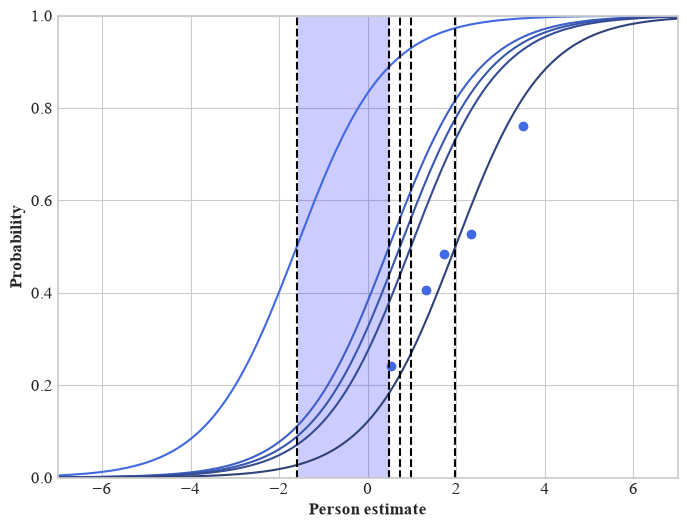

In [40]:
mfrm.threshold_ccs_centrality('Item_2', thresh_lines=True, obs=[5], cat_highlight=1, xmin=-7, xmax=7, filename='my_mfrm_centrality_threshold_ccs')

Produce an item information function curve for Item 2

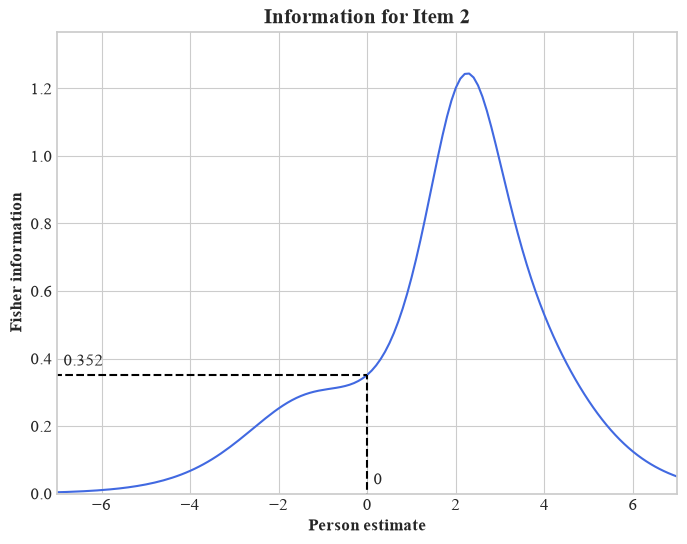

In [41]:
mfrm.iic_centrality('Item_2', point_info_lines=[0], point_info_labels=True,
                    title='Information for Item 2', xmin=-7, xmax=7, filename='my_mfrm_centrality_iic')

Produce a test characteristic curve (test response function), with person locations corresponding to scores of 150 and 250 (aggregated across all raters) plotted.

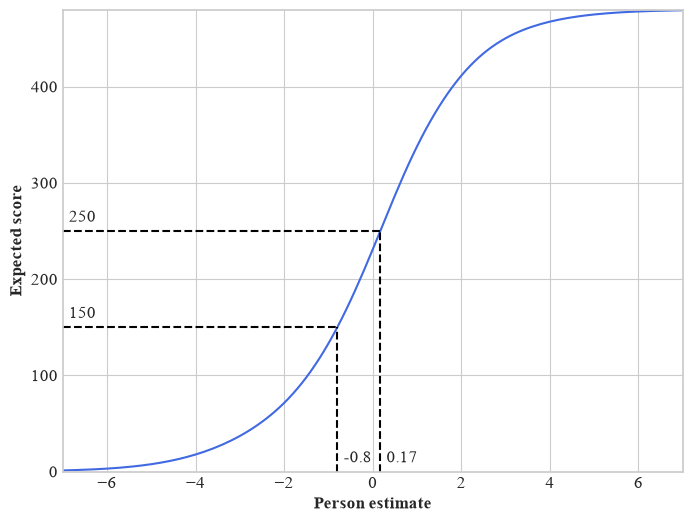

In [42]:
mfrm.tcc_centrality(score_lines=[150, 250], score_labels=True, xmin=-7, xmax=7, filename='my_mfrm_centrality_tcc')

Produce a test information curve

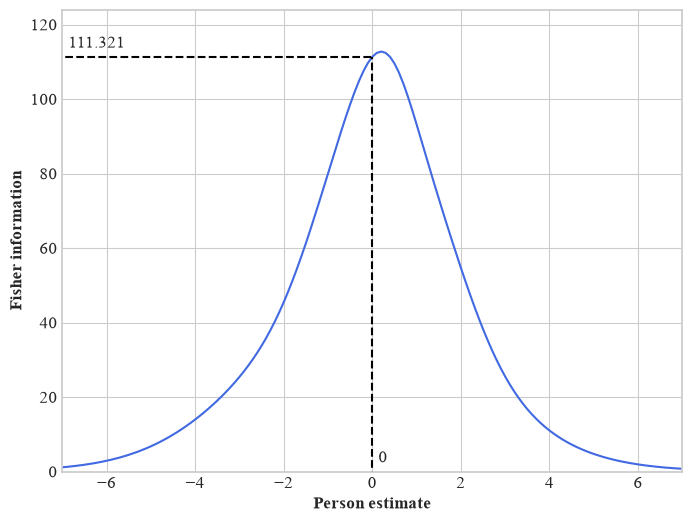

In [43]:
mfrm.test_info_centrality(point_info_lines=[0], point_info_labels=True,
                          xmin=-7, xmax=7, filename='my_mfrm_centrality_test_info_curve')

Produce a test CSEM (conditional standard error of measurement) curve, with the CSEM corresponding to a person location of -3 plotted

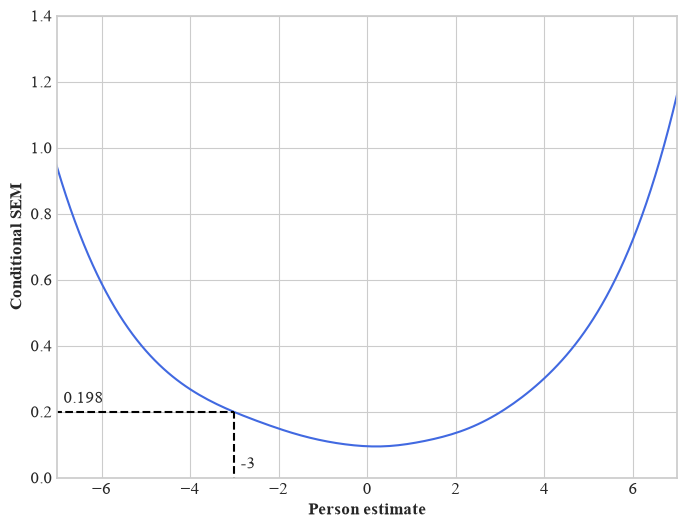

In [44]:
mfrm.test_csem_centrality(point_csem_lines=[-3], point_csem_labels=True, ymax=1.4, xmin=-7, xmax=7, filename='my_mfrm_centrality_csem_curve')

Produce a histogram of standardised residuals, with a normal distribution curve overlaid

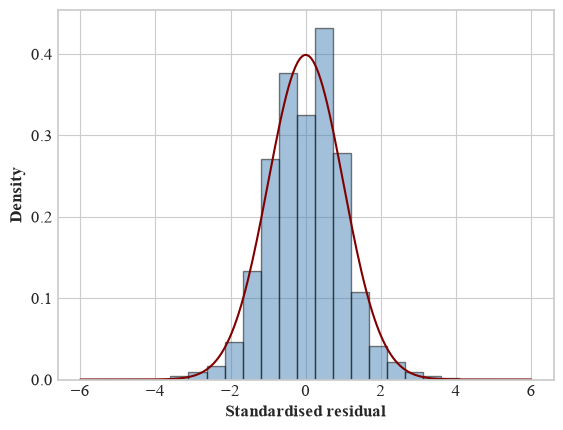

In [45]:
mfrm.std_residuals_plot_centrality(bin_width=0.6, normal=True, filename='my_mfrm_centrality_std_residuals_plot')

**Model selection.** Since `centrality` is nested between `global` and `thresholds`, `model_selection()` can compare it against all eight MFRM rater representations (or a chosen subset via `models=`) directly via AIC, BIC, or LR. See the `Model selection` example notebook for a full worked demonstration, including a direct three-way comparison of the stretch representations (`models=['centrality', 'pseudo_halo', 'bistretch']`).

Now run an anchored analysis, anchoring to the mean severity of Raters 1-4 (e.g. a set of 'gold standard' raters).

In [46]:
%%time
anchors = ['Rater_1', 'Rater_2', 'Rater_3', 'Rater_4']
mfrm.calibrate_centrality_anchor(anchors)

CPU times: user 16 ms, sys: 2.73 ms, total: 18.8 ms
Wall time: 16.4 ms


Check the anchored thresholds against the unanchored thresholds

In [47]:
threshold_check = pd.DataFrame({'Unanchored': mfrm.thresholds,
                           'Anchored': mfrm.anchor_thresholds_centrality})
round(threshold_check, 3)

,Unanchored,Anchored
1,-2.115,-1.908
2,-0.031,-0.023
3,0.217,0.183
4,0.463,0.434
5,1.467,1.314


Check the anchored rater x threshold severities against the unanchored ones (two separate dataframes).

In [48]:
round(mfrm.raters_centrality, 3)

,1,2,3,4,5
Rater_1,0.164,1.283,1.415,1.547,2.086
Rater_2,0.781,-0.186,-0.301,-0.415,-0.881
Rater_3,1.692,0.986,0.902,0.819,0.479
Rater_4,-0.159,-0.443,-0.477,-0.511,-0.647
Rater_5,-0.737,-0.225,-0.165,-0.105,0.142
Rater_6,-1.176,-0.757,-0.708,-0.658,-0.456
Rater_7,-0.358,-0.400,-0.405,-0.409,-0.429
Rater_8,-0.210,-0.266,-0.272,-0.279,-0.306


In [49]:
round(mfrm.anchor_raters_centrality, 3)

,1,2,3,4,5
Rater_1,-0.469,0.857,1.002,1.179,1.798
Rater_2,0.159,-0.604,-0.688,-0.789,-1.145
Rater_3,1.070,0.574,0.520,0.454,0.222
Rater_4,-0.764,-0.874,-0.886,-0.901,-0.952
Rater_5,-1.356,-0.630,-0.551,-0.454,-0.116
Rater_6,-1.799,-1.169,-1.101,-1.017,-0.723
Rater_7,-0.981,-0.814,-0.795,-0.773,-0.695
Rater_8,-0.834,-0.679,-0.662,-0.641,-0.569
